# Sales Prediction Using Python

## Objective

The objective of this project is to build a machine learning regression model that predicts product sales based on advertising expenditure across different media channels.

The dataset contains advertising budgets spent on:
- TV
- Radio
- Newspaper

The model learns the relationship between advertising spending and sales to predict future sales values.

## Machine Learning Approach

This project uses regression techniques:
- Linear Regression (Baseline Model)
- Random Forest Regressor (Advanced Model)

The models are evaluated using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

# Importing Required Libraries

The required Python libraries are imported for:

- Data manipulation using pandas and numpy
- Data visualization using matplotlib and seaborn
- Machine learning model development using scikit-learn
- Model evaluation using regression metrics

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Loading Dataset

The Advertising dataset is loaded into a pandas DataFrame.

The dataset contains information about advertising expenditure on different platforms and the corresponding product sales.

### Features:
- TV: Advertising spending on television
- Radio: Advertising spending on radio
- Newspaper: Advertising spending on newspapers

### Target:
- Sales: Product sales generated

In [15]:
df = pd.read_csv("Advertising.csv")

df.rename(columns={
    "TV Ad Budget ($)": "TV",
    "Radio Ad Budget ($)": "Radio",
    "Newspaper Ad Budget ($)": "Newspaper",
    "Sales ($)": "Sales"
}, inplace=True)

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [18]:
import pandas as pd

df = pd.read_csv("Advertising.csv")

df.rename(columns={
    "TV Ad Budget ($)": "TV",
    "Radio Ad Budget ($)": "Radio",
    "Newspaper Ad Budget ($)": "Newspaper",
    "Sales ($)": "Sales"
}, inplace=True)

df.drop("Unnamed: 0", axis=1, inplace=True)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


# Dataset Information

The dataset information is checked to understand:

- Number of rows and columns
- Data types of each feature
- Memory usage
- Presence of missing values

This helps identify data quality issues before model training.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


# Checking Missing Values

Missing values can affect machine learning model performance.

The dataset is checked for null values to ensure that the data is clean and ready for analysis.

In [20]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

# Descriptive Statistics

Descriptive statistics provide a summary of numerical features.

The analysis includes:

- Mean
- Standard deviation
- Minimum value
- Maximum value
- Quartile distribution

This helps understand the range and distribution of advertising expenses and sales.

In [21]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand relationships between advertising channels and sales.

A pairplot is created to visualize:

- Relationships between all numerical variables
- Distribution of individual features
- Possible trends and patterns in the dataset

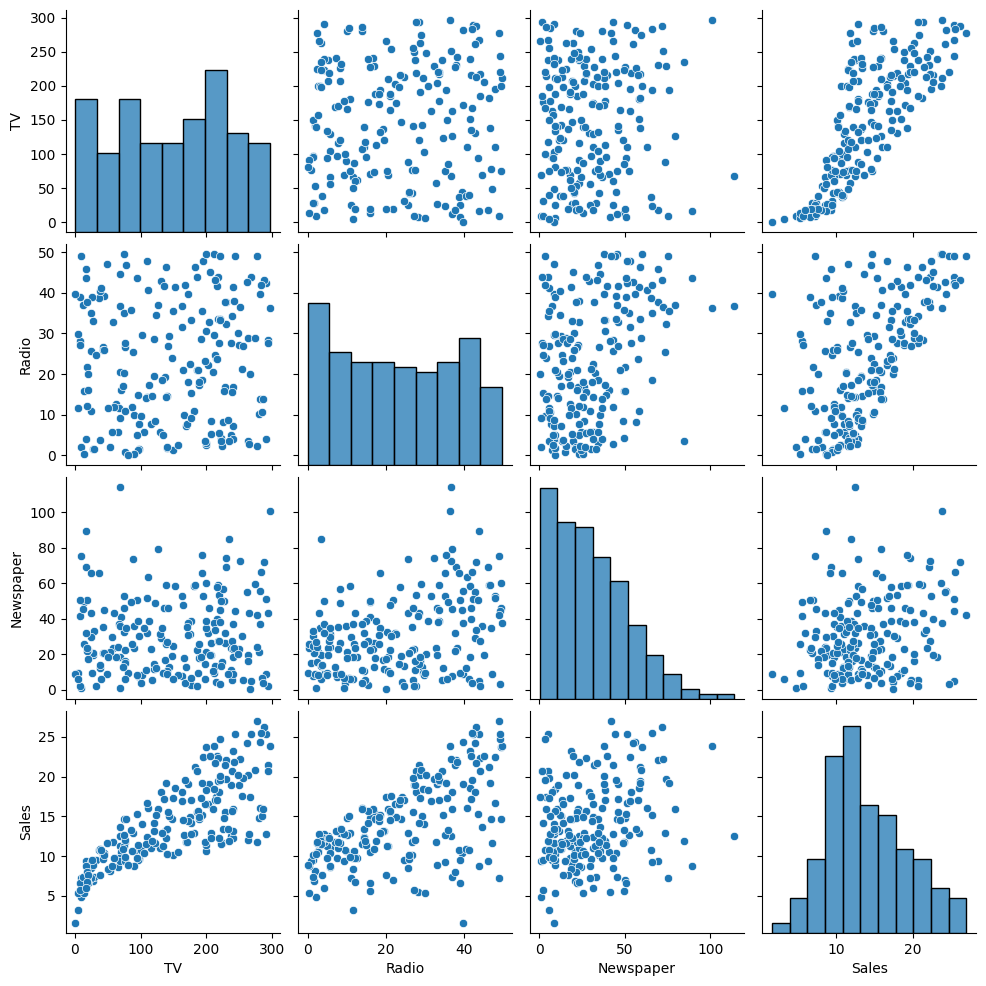

In [22]:
sns.pairplot(df)

plt.show()

# Relationship Between Advertising Channels and Sales

Scatter plots are created to analyze how each advertising medium affects product sales.

The following relationships are studied:

1. TV Advertising vs Sales
2. Radio Advertising vs Sales
3. Newspaper Advertising vs Sales

These visualizations help identify which advertising channel has the strongest relationship with sales.

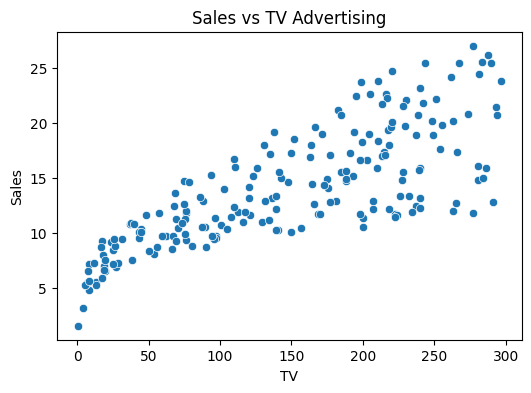

In [23]:
plt.figure(figsize=(6,4))

sns.scatterplot(x="TV", y="Sales", data=df)

plt.title("Sales vs TV Advertising")

plt.show()

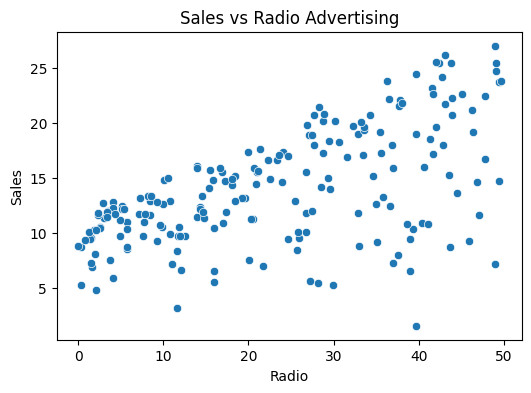

In [24]:
plt.figure(figsize=(6,4))

sns.scatterplot(x="Radio", y="Sales", data=df)

plt.title("Sales vs Radio Advertising")

plt.show()

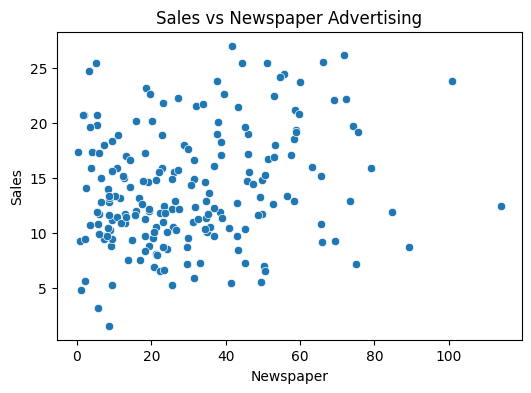

In [25]:
plt.figure(figsize=(6,4))

sns.scatterplot(x="Newspaper", y="Sales", data=df)

plt.title("Sales vs Newspaper Advertising")

plt.show()

# Correlation Analysis

A correlation matrix is used to measure the relationship between numerical variables.

Correlation values range from:

- +1 → Strong positive relationship
- 0 → No relationship
- -1 → Strong negative relationship

The heatmap helps identify which advertising channels have the highest correlation with sales.

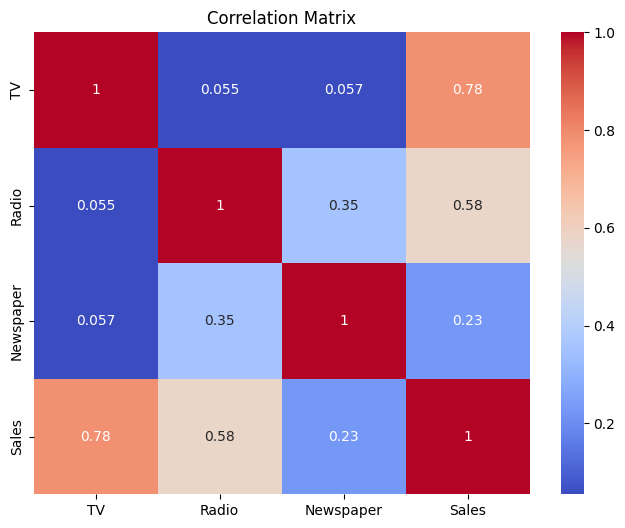

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

# Feature Selection

The dataset is divided into:

## Independent Variables (Features)

Advertising expenditure:
- TV
- Radio
- Newspaper

## Dependent Variable (Target)

- Sales

The machine learning model learns the relationship between advertising spending and sales.

In [27]:
X = df[['TV', 'Radio', 'Newspaper']]

y = df['Sales']

# Splitting Dataset into Training and Testing Data

The dataset is divided into training and testing sets.

Training data:
- Used to train the machine learning model.

Testing data:
- Used to evaluate model performance on unseen data.

80% data is used for training and 20% data is used for testing.

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Linear Regression Model

Linear Regression is used as the baseline machine learning model.

It assumes a linear relationship between advertising expenditure and sales.

The model learns an equation:

Sales = Intercept + (TV coefficient × TV) + (Radio coefficient × Radio) + (Newspaper coefficient × Newspaper)

This model provides a simple and interpretable prediction approach.

In [45]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [46]:
lr_pred = lr.predict(X_test)

# Model Evaluation Metrics

The Linear Regression model is evaluated using:

## Mean Absolute Error (MAE)

Measures the average absolute difference between actual and predicted values.

Lower MAE indicates better performance.

## Root Mean Squared Error (RMSE)

Measures prediction error while giving more importance to larger errors.

Lower RMSE indicates better performance.

## R² Score

Measures how well the model explains variation in sales.

Higher R² indicates better prediction capability.

In [47]:
mae = mean_absolute_error(y_test, lr_pred)

print("MAE:", mae)

MAE: 1.4607567168117606


In [48]:
rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("RMSE:", rmse)

RMSE: 1.7815996615334502


In [49]:
r2 = r2_score(y_test, lr_pred)

print("R2 Score:", r2)

R2 Score: 0.899438024100912


# Random Forest Regression Model

Random Forest Regressor is an ensemble machine learning algorithm.

It creates multiple decision trees and combines their predictions to improve accuracy.

Advantages:
- Handles non-linear relationships
- Reduces overfitting
- Provides feature importance values

In [50]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [51]:
rf_pred = rf.predict(X_test)

# Comparing Machine Learning Models

Both models are compared using:

- MAE
- RMSE
- R² Score

The model with lower error values and higher R² score is considered the better performing model.

In [52]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

MAE: 0.6200999999999988
RMSE: 0.7685910811348248
R2 Score: 0.9812843792541843


In [53]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R2 Score": [r2, rf_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.620100,0.768591,0.981284


# Residual Analysis

Residual analysis is performed to evaluate the quality of the regression model.

A residual is calculated as:

**Residual = Actual Sales − Predicted Sales**

The residual plot helps determine whether the model has learned the relationship correctly.

A good regression model should produce residuals that are randomly scattered around the zero line without any visible pattern.

If a clear pattern or trend is observed, it may indicate that the model has not captured all the relationships present in the data.

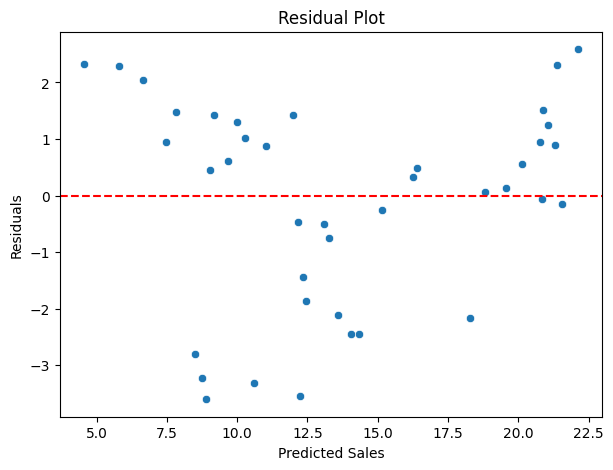

In [54]:
residuals = y_test - lr_pred

plt.figure(figsize=(7,5))

sns.scatterplot(x=lr_pred, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [55]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coefficients

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


# Feature Importance Analysis

Feature importance is calculated to understand which advertising channel contributes most to sales prediction.

This helps answer:

"Which advertising platform has the highest impact on sales?"

The importance is calculated using:

- Linear Regression coefficients
- Random Forest feature importance

In [56]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
0,TV,0.624810
1,Radio,0.362201
2,Newspaper,0.012989


# Distribution of Features

Histograms are used to understand the distribution of numerical variables in the dataset.

They help identify:

- The frequency of values
- Data spread
- Skewness
- Potential outliers

Understanding the distribution of each feature is an important step before building a machine learning model.

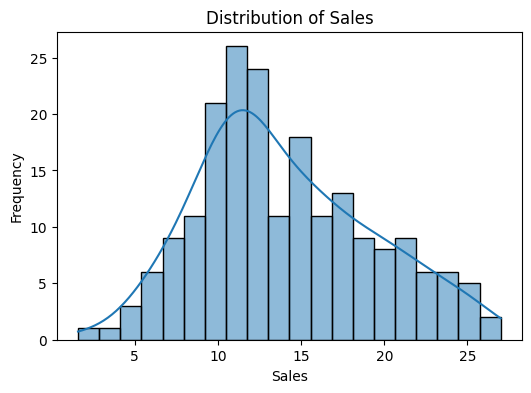

In [57]:
plt.figure(figsize=(6,4))
sns.histplot(df["Sales"], bins=20, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

In [58]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

# Feature Importance

This bar plot illustrates the contribution of each advertising channel to the sales prediction model.

Features with higher importance have a greater influence on predicting product sales.

By comparing the importance values, we can identify which advertising medium has the strongest impact on sales.

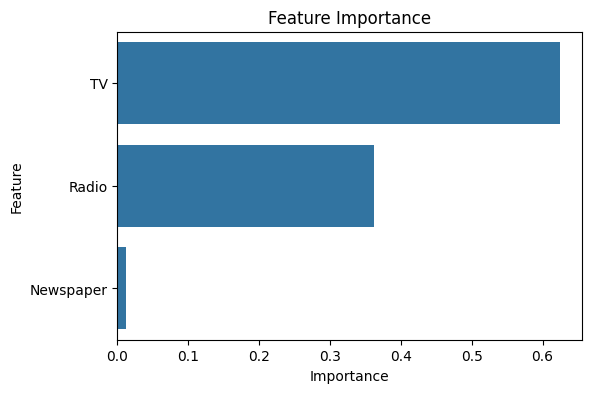

In [59]:
plt.figure(figsize=(6,4))

sns.barplot(x="Importance", y="Feature", data=importance)

plt.title("Feature Importance")

plt.show()

# Actual vs Predicted Sales

This visualization compares the actual sales values with the sales predicted by the machine learning model.

A well-performing model should produce predicted values that closely match the actual values.

If most points lie near the reference line, it indicates that the model is making accurate predictions.

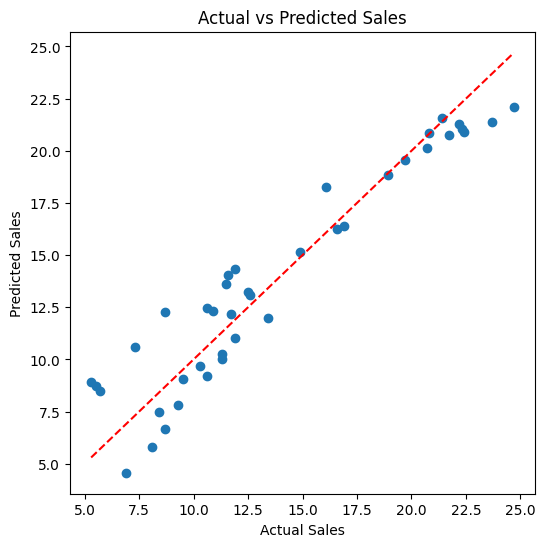

In [60]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, lr_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

# Interpretation

Based on model analysis:

- TV advertising shows the strongest influence on product sales.
- Radio advertising also contributes significantly toward sales prediction.
- Newspaper advertising has comparatively lower impact.

The results indicate that investing in effective advertising channels can improve sales performance.

# Conclusion

In this project, a sales prediction system was developed using machine learning techniques.

The workflow included:

- Data loading and preprocessing
- Exploratory Data Analysis
- Visualization of feature relationships
- Correlation analysis
- Model training using Linear Regression and Random Forest Regression
- Model evaluation using MAE, RMSE, and R² score
- Residual analysis
- Feature importance evaluation

The project successfully demonstrates how machine learning can be used to predict product sales based on advertising expenditure.

# Future Improvements

The project can be enhanced in several ways:

- Train additional regression models such as Polynomial Regression or XGBoost.
- Perform hyperparameter tuning to improve model performance.
- Use larger and more diverse advertising datasets.
- Deploy the model as a web application using Streamlit or Flask.
- Integrate real-time advertising data for live sales prediction.